# TechMind — Entrenamiento del modelo

**Ciencia de Datos · Hackathon ONE (Alura + Oracle) · G9 LatAm**

TechMind organiza conocimiento técnico de forma automática. Este notebook entrena y
empaqueta el modelo que hace ese trabajo.

Dado un texto técnico —un artículo, un apunte, una página de documentación— el modelo
determina **a qué categoría pertenece**, **qué términos lo definen**, **en qué zona del
mapa temático cae** y **qué vector lo representa** para poder encontrar contenido
relacionado.

## Qué entra y qué sale

| | |
|---|---|
| **Entra** | `processed/*.jsonl` — el corpus ya limpio, que produce el notebook de EDA/ETL |
| **Sale** | `model/model.joblib` — los modelos entrenados, que carga el servicio de inferencia |
| **Sale** | `model/corpus_index.npz` — los vectores del corpus, que siembran la base de datos |

## Cómo está organizado

| Parte | Contenido |
|---|---|
| **A · Entrenamiento** | corpus → embeddings → clasificación → agrupamiento → mapa → palabras clave |
| **B · Uso** | el contrato del servicio, la búsqueda semántica y cómo crece la base de conocimiento |
| **C · Empaquetado** | serialización de los artefactos y publicación en OCI Object Storage |

## Las 8 categorías

Backend · Frontend · Móvil · Datos e IA · DevOps y Cloud · Bases de datos ·
Seguridad · Fundamentos

Cada contenido pertenece a **una sola**.

In [1]:
# Dependencias (Colab, CPU o GPU). Las versiones van fijadas para que dos personas
# que ejecuten este notebook obtengan exactamente los mismos números.
!pip -q install sentence-transformers==5.6.1 umap-learn==0.5.12 scikit-learn==1.9.0 joblib==1.5.3 matplotlib==3.11.1

## Parte A — Entrenamiento

### 1. Imports

In [2]:
import json, pathlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer
import umap
import joblib

### 2. Configuración

Todo lo ajustable vive aquí, en un solo sitio. Los parámetros que más cambian el
resultado son estos cuatro:

| Parámetro | Qué controla | Si lo subes | Si lo bajas |
|---|---|---|---|
| `CLASSIFIER_C` | cuánta libertad tiene el clasificador para ajustarse a los datos | se ajusta más al entrenamiento | generaliza más, pero puede quedarse corto |
| `SVD_COMPONENTS` | cuánta información del vocabulario literal recibe el clasificador | más señal, artefacto más grande | menos señal, más ligero. Con `0` se usa solo el embedding |
| `N_CLUSTERS` | en cuántos grupos temáticos se divide el corpus | agrupaciones más finas | agrupaciones más amplias |
| `TFIDF_MAX_FEATURES` | tamaño del vocabulario de los TF-IDF | vocabulario más rico, artefacto más pesado | más ligero, pierde términos poco frecuentes |

`SEED = 42` está fijado en cada división, modelo y proyección: **dos personas que
ejecuten este notebook obtienen exactamente los mismos números.**

In [3]:
SEED = 42

# Modelo de embeddings
# E5 multilingüe: sitúa "proteger una API con tokens" y "secure an API with tokens"
# en la misma región del espacio vectorial, que es lo que permite clasificar y buscar
# en español con un corpus mayoritariamente en inglés.
EMBEDDING_MODEL = "intfloat/multilingual-e5-small"
EMBEDDING_DIM   = 384
DOC_PREFIX      = "passage: "     # E5 distingue documentos...
QUERY_PREFIX    = "query: "       # ...de consultas, y hay que decírselo

# Las 8 categorías oficiales (un contenido pertenece a una sola).
CATEGORIES = ["Backend", "Frontend", "Móvil", "Datos e IA",
              "DevOps y Cloud", "Bases de datos", "Seguridad", "Fundamentos"]
VALID_LANGUAGES = {"es", "en"}

# --- Rutas ---
DATA_DIR  = pathlib.Path("processed")   # entrada: corpus del notebook de EDA/ETL
MODEL_DIR = pathlib.Path("model")       # salida: artefactos entrenados

TRAIN_PATH   = DATA_DIR / "train_corpus.jsonl"
TEST_EN_PATH = DATA_DIR / "test_corpus.jsonl"      # evaluación en inglés
TEST_ES_PATH = DATA_DIR / "test_corpus_es.jsonl"   # evaluación en español

MODEL_PATH  = MODEL_DIR / "model.joblib"
INDEX_PATH  = MODEL_DIR / "corpus_index.npz"
LATEST_PATH = MODEL_DIR / "latest.txt"

MODEL_VERSION = "v1"

# Parámetros ajustables
N_CLUSTERS    = 8      # grupos temáticos que descubre KMeans
N_KEYWORDS    = 6      # palabras clave por contenido
N_EXPLANATION = 5      # términos que justifican la categoría

# Regularización del clasificador (inversa de la fuerza). La sección 8 compara este
# valor contra uno más suelto en cada corrida, así que el efecto de cambiarlo se ve
# medido y no hay que suponerlo.
CLASSIFIER_C = 1.0

# Dimensiones de vocabulario que se suman al embedding para clasificar (sección 6).
# Poner 0 desactiva esa combinación y el clasificador trabaja solo con el embedding.
SVD_COMPONENTS = 500

# Documentos por lote al generar embeddings. 64 va bien en GPU T4; si aparece un
# error de memoria, bájalo a 32 o 16.
BATCH_SIZE = 64

# Vocabulario de los TF-IDF. Con min_df=1, cada errata del corpus se convierte en un
# término propio: el vocabulario se dispara y el artefacto engorda sin aportar señal.
TFIDF_MIN_DF       = 3
TFIDF_MAX_FEATURES = 50_000

# Conectores que se excluyen del vocabulario. Sin esta lista, "de", "con" o "the"
# aparecerían como palabras clave: son los tokens más frecuentes de cualquier texto,
# y el TF-IDF los recoge igual que a un término técnico.
# Van sin acentos porque los vectorizers usan strip_accents="unicode", así que "más"
# llega a la comparación ya convertido en "mas".
SPANISH_STOPWORDS = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un",
    "para", "con", "no", "una", "su", "al", "es", "lo", "como", "mas", "o", "pero",
    "sus", "le", "ya", "este", "esta", "son", "entre", "cuando", "muy", "sin", "sobre",
    "ser", "tiene", "tambien", "hasta", "hay", "donde", "han", "quien", "estan", "cada",
    "porque", "puede", "pueden", "debe", "solo", "todo", "toda", "otro", "otra",
}
ENGLISH_STOPWORDS = {
    "the", "of", "and", "to", "in", "a", "is", "that", "it", "for", "on", "with", "as",
    "are", "this", "be", "by", "or", "an", "from", "at", "can", "you", "your", "we",
    "not", "have", "has", "but", "they", "their", "which", "will", "more", "than",
    "when", "what", "how", "its", "into", "only", "each", "one", "two", "them", "so",
}
STOPWORDS = SPANISH_STOPWORDS | ENGLISH_STOPWORDS

# Configuración compartida por los TF-IDF del notebook.
TFIDF_PARAMS = dict(
    ngram_range=(1, 2),
    min_df=TFIDF_MIN_DF,
    max_features=TFIDF_MAX_FEATURES,
    stop_words=sorted(STOPWORDS),
    strip_accents="unicode",
    sublinear_tf=True,
)

# Un color fijo por categoría, en el orden de CATEGORIES, para que una categoría se
# reconozca de un vistazo entre figuras distintas.
COLORS = plt.get_cmap("tab10").colors[:8]

### 3. Carpetas de trabajo

`processed/` guarda el corpus de entrada y `model/` los artefactos que produce este
notebook. Se crean si no existen, de modo que el notebook funcione en un Colab recién
abierto sin ningún paso manual.

In [4]:
for folder in (DATA_DIR, MODEL_DIR):
    existed = folder.exists()
    folder.mkdir(parents=True, exist_ok=True)
    print(f"  {str(folder) + '/':<14} {'ya existía' if existed else 'creada'}")

if not TRAIN_PATH.exists():
    print(f"\n⚠️  No se encuentra {TRAIN_PATH}")
    print("    Ejecuta antes el notebook de EDA/ETL (data/TechMind_01_EDA_ETL.ipynb),")
    print(f"    o sube los .jsonl del corpus a la carpeta '{DATA_DIR}/'.")

  processed/     ya existía
  model/         ya existía


### 4. Carga del corpus

El corpus llega **ya limpio** desde el notebook de EDA/ETL: aquí solo se carga y se
verifica que trae los campos que el resto del notebook espera.

Se cargan **tres conjuntos**, y la separación es deliberada:

- **Entrenamiento** — con lo que aprende el modelo.
- **Test en inglés** — mide la calidad del clasificador en el idioma mayoritario del corpus.
- **Test en español** — mide algo distinto: si lo aprendido **se transfiere a otro
  idioma**. Es la medida que importa para el producto, porque la interfaz es en español.

Ningún documento de test participa en el entrenamiento.

In [5]:
def load_corpus(path: pathlib.Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Falta {path}. Sube el corpus limpio a '{DATA_DIR}/'.")
    rows = [json.loads(line) for line in path.open(encoding="utf-8") if line.strip()]
    frame = pd.DataFrame(rows)
    missing = {"id", "title", "body", "category"} - set(frame.columns)
    if missing:
        raise ValueError(f"{path.name}: faltan columnas {sorted(missing)}")
    for optional in ("source", "url", "language"):
        if optional not in frame.columns:
            frame[optional] = None
    frame["language"] = frame["language"].fillna("es")
    return frame

train_df   = load_corpus(TRAIN_PATH)
test_es_df = load_corpus(TEST_ES_PATH)
# El conjunto en inglés es opcional: si no está, se evalúa solo en español.
test_en_df = load_corpus(TEST_EN_PATH) if TEST_EN_PATH.exists() else None
print(f"entrenamiento : {len(train_df)} documentos")
print(f"test español  : {len(test_es_df)} documentos")
print(f"test inglés   : {len(test_en_df) if test_en_df is not None else 0} documentos")

entrenamiento : 12800 documentos
test español  : 320 documentos
test inglés   : 3200 documentos


### 5. Composición del corpus

Dos cosas que conviene ver antes de entrenar:

- **Cuántos documentos hay por categoría.** La métrica de evaluación (macro-F1) da el
  mismo peso a las ocho, así que una categoría con pocos ejemplos penaliza igual que
  una grande.
- **De qué fuente viene cada categoría.** Si una categoría procediera de una única
  fuente, el modelo podría estar aprendiendo el estilo de esa fuente en lugar del tema.

                documentos   es    en
category                             
Backend               1600  387  1213
Frontend              1600  406  1194
Móvil                 1600  376  1224
Datos e IA            1600  395  1205
DevOps y Cloud        1600  416  1184
Bases de datos        1600  336  1264
Seguridad             1600  182  1418
Fundamentos           1600  335  1265

Total: 12800 documentos  ·  22% español / 78% inglés

✅ el corpus cubre las 8 categorías oficiales


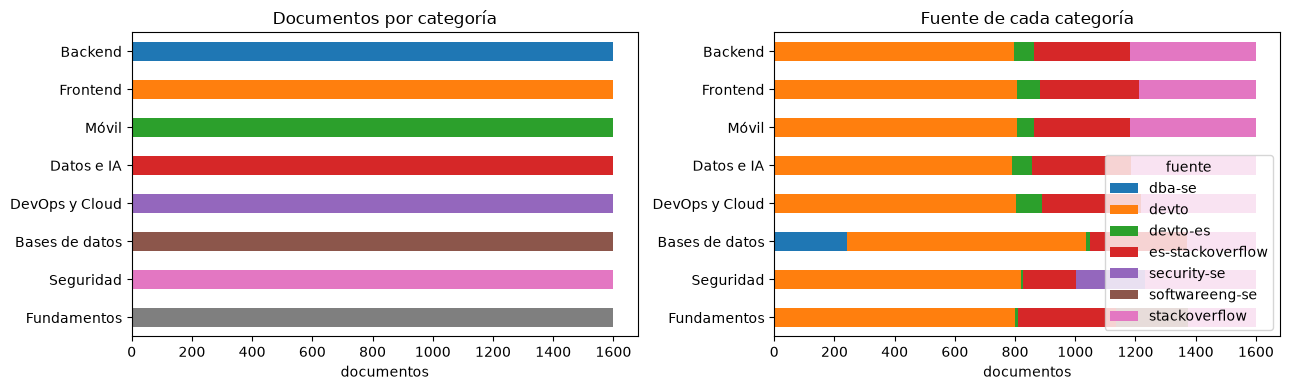

In [6]:
summary = (train_df.groupby("category")
           .agg(documentos=("id", "count"),
                es=("language", lambda s: (s == "es").sum()),
                en=("language", lambda s: (s == "en").sum()))
           .reindex(CATEGORIES).fillna(0).astype(int))
print(summary.to_string())
print(f"\nTotal: {len(train_df)} documentos"
      f"  ·  {train_df['language'].eq('es').mean():.0%} español"
      f" / {train_df['language'].eq('en').mean():.0%} inglés")

missing = set(CATEGORIES) - set(train_df["category"])
assert not missing, f"El corpus no cubre las 8 categorías. Faltan: {missing}"
print("\n✅ el corpus cubre las 8 categorías oficiales")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
summary["documentos"].plot(kind="barh", ax=ax1, color=COLORS)
ax1.set_title("Documentos por categoría"); ax1.set_xlabel("documentos"); ax1.set_ylabel("")
ax1.invert_yaxis()

if "source" in train_df.columns:
    (train_df.pivot_table(index="category", columns="source", values="id",
                          aggfunc="count", fill_value=0).reindex(CATEGORIES)
     .plot(kind="barh", stacked=True, ax=ax2))
    ax2.set_title("Fuente de cada categoría"); ax2.set_xlabel("documentos")
    ax2.set_ylabel(""); ax2.invert_yaxis()
    ax2.legend(title="fuente", loc="lower right")
else:
    ax2.axis("off")
plt.tight_layout(); plt.show()

### 6. Embeddings multilingües

Cada documento se convierte en un **vector de 384 números** que representa su
significado. Textos que hablan de lo mismo quedan cerca en ese espacio, **aunque estén
escritos en idiomas distintos**: es lo que permite que un modelo entrenado
mayoritariamente con textos en inglés clasifique contenido en español.

E5 distingue entre **documentos** (lo que se indexa) y **consultas** (lo que se busca),
y hay que indicárselo con un prefijo. Por eso hay dos funciones y no una: usar el
prefijo equivocado degrada los resultados de forma silenciosa, sin ningún error.

Los vectores salen **normalizados**, lo que hace que medir similitud entre dos textos
sea tan barato como un producto escalar.

In [7]:
# El dispositivo decide cuánto tarda esta sección: en GPU son 1-2 minutos para todo el
# corpus; en CPU puede irse a 30-60. Conviene saberlo antes de empezar a esperar.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
encoder = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)

print(f"dispositivo: {DEVICE}")
if DEVICE == "cpu":
    print("⚠️  Sin GPU. Embeber miles de documentos tardará bastante.")
    print("    En Colab: Entorno de ejecución → Cambiar tipo de entorno → GPU (T4)")

def _document(row) -> str:
    return f"{row['title']}. {row['body']}"

def embed_documents(texts, progress=None):
    """Vectoriza CONTENIDO, para indexarlo."""
    return encoder.encode([DOC_PREFIX + t for t in texts],
                          normalize_embeddings=True, batch_size=BATCH_SIZE,
                          show_progress_bar=len(texts) > 32 if progress is None else progress)

def embed_queries(texts, progress=None):
    """Vectoriza CONSULTAS, para buscar."""
    return encoder.encode([QUERY_PREFIX + t for t in texts],
                          normalize_embeddings=True, batch_size=BATCH_SIZE,
                          show_progress_bar=len(texts) > 32 if progress is None else progress)

train_docs   = [_document(r) for _, r in train_df.iterrows()]
test_es_docs = [_document(r) for _, r in test_es_df.iterrows()]

X_train   = embed_documents(train_docs)
X_test_es = embed_documents(test_es_docs)

if test_en_df is not None:
    test_en_docs = [_document(r) for _, r in test_en_df.iterrows()]
    X_test_en = embed_documents(test_en_docs)

print("embeddings de entrenamiento:", X_train.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

dispositivo: cuda


Batches:   0%|          | 0/200 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

embeddings de entrenamiento: (12800, 384)


### 7. Clasificación

Se entrenan **dos modelos**, cada uno con un propósito:

- **El modelo de producción**, que es el que clasifica el contenido nuevo.
- **Un modelo explicable** (TF-IDF + regresión logística), que no clasifica en
  producción pero permite responder *"¿por qué esta categoría?"* señalando los términos
  concretos del texto que empujaron la decisión. Es lo que alimenta el campo
  `explanation` del contrato.

#### El clasificador combina dos representaciones

El modelo de producción no ve solo el embedding. Ve el **embedding concatenado con una
versión comprimida del vocabulario literal del texto**, porque las dos
representaciones fallan en sitios distintos y se compensan:

| | Qué capta bien | Qué se le escapa |
|---|---|---|
| **Embedding (E5)** | el significado, y a través de idiomas | los nombres propios técnicos, que difumina |
| **TF-IDF** | términos exactos: `Kubernetes`, `PostgreSQL`, `OAuth` | que "proteger una API" y "secure an API" son lo mismo |

El TF-IDF completo tendría decenas de miles de dimensiones, demasiadas para
concatenarlas. Se comprime con SVD a `SVD_COMPONENTS` dimensiones, que conservan lo
esencial en un espacio manejable.

Los dos bloques se normalizan a la misma escala antes de unirlos: si uno entrara con
valores mucho mayores que el otro, la regularización castigaría al pequeño y su
aportación se perdería.

> **Dos dimensiones distintas, y no son intercambiables.** El clasificador consume
> `384 + SVD_COMPONENTS` valores. Pero lo que se guarda en la base de datos y lo que
> viaja en el contrato es **siempre el embedding de 384**, porque es el espacio sobre
> el que la base resuelve la búsqueda por similitud.

In [8]:
label_encoder = LabelEncoder().fit(CATEGORIES)
y_train   = label_encoder.transform(train_df["category"])
y_test_es = label_encoder.transform(test_es_df["category"])
if test_en_df is not None:
    y_test_en = label_encoder.transform(test_en_df["category"])

# TF-IDF, ajustado únicamente con los datos de entrenamiento ---
# El vectorizador se entrena solo con el conjunto de entrenamiento para evitar
# que la información del conjunto de prueba influya en la evaluación del modelo.
baseline_vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
Xtfidf_train = baseline_vectorizer.fit_transform(train_docs)
baseline_classifier = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xtfidf_train, y_train)

# Los nombres de las características se obtienen una sola vez y luego se reutilizan
# cuando se generan las explicaciones del modelo, evitando cálculos innecesarios.
baseline_feature_names = np.array(baseline_vectorizer.get_feature_names_out())
print(f"modelo explicable entrenado (vocabulario: {len(baseline_vectorizer.vocabulary_)} términos)")

# Compresión del vocabulario
if SVD_COMPONENTS:
    svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=SEED).fit(Xtfidf_train)

    # Se almacenan los componentes en precisión float32 para reducir el tamaño
    # del modelo sin afectar de forma apreciable los resultados obtenidos.
    # La conversión se realiza antes del entrenamiento para que el clasificador
    # utilice exactamente la misma representación durante entrenamiento e inferencia.
    svd.components_ = svd.components_.astype("float32")

    print(f"vocabulario comprimido a {SVD_COMPONENTS} dimensiones "
          f"({100 * svd.explained_variance_ratio_.sum():.1f} % de la varianza conservada, "
          f"{svd.components_.nbytes / 1e6:.0f} MB)")
else:
    svd = None
    print("compresión desactivada: el clasificador usa solo el embedding")

def build_features(embeddings, documents):
    """Construye lo que ve el CLASIFICADOR: embedding + vocabulario comprimido.

    No es lo que se guarda en la base de datos. El contrato expone siempre el
    embedding de 384 dimensiones, que es sobre el que corre la búsqueda.
    """
    if svd is None:
        return embeddings
    reduced = normalize(svd.transform(baseline_vectorizer.transform(documents)))
    return np.hstack([embeddings, reduced])

F_train   = build_features(X_train, train_docs)
F_test_es = build_features(X_test_es, test_es_docs)
if test_en_df is not None:
    F_test_en = build_features(X_test_en, test_en_docs)

#Modelo de producción
classifier = LogisticRegression(C=CLASSIFIER_C, class_weight="balanced",
                                max_iter=2000, random_state=SEED).fit(F_train, y_train)
print(f"clasificador entrenado con {len(F_train)} documentos "
      f"y {F_train.shape[1]} características por documento")

modelo explicable entrenado (vocabulario: 48730 términos)
vocabulario comprimido a 500 dimensiones (26.4 % de la varianza conservada, 97 MB)
clasificador entrenado con 12800 documentos y 884 características por documento


### 8. Evaluación

La métrica es **macro-F1**, no exactitud. La diferencia importa: la exactitud premia
acertar en las categorías grandes y puede ser alta aunque el modelo falle
sistemáticamente en las pequeñas. La macro-F1 da **el mismo peso a las ocho
categorías**, así que refleja si el modelo funciona para todas.

Se mide en dos escenarios, y la comparación entre ambos es informativa por sí sola:

- **Inglés** — el idioma mayoritario del entrenamiento. Mide la calidad del clasificador.
- **Español** — mide si lo aprendido **se transfiere** al idioma de la interfaz.

La tabla incluye también qué aporta cada pieza del diseño, para que las decisiones de
la sección anterior queden respaldadas por números en cada ejecución.

In [9]:
def macro_f1(model, X, y):
    return round(float(f1_score(y, model.predict(X), average="macro")), 4)

# Modelo de producción
embedding_macro_f1_es = macro_f1(classifier, F_test_es, y_test_es)
tfidf_macro_f1_es     = macro_f1(baseline_classifier,
                                 baseline_vectorizer.transform(test_es_docs), y_test_es)

if test_en_df is not None:
    embedding_macro_f1_en = macro_f1(classifier, F_test_en, y_test_en)
    tfidf_macro_f1_en     = macro_f1(baseline_classifier,
                                     baseline_vectorizer.transform(test_en_docs), y_test_en)
else:
    embedding_macro_f1_en = tfidf_macro_f1_en = None

# Comparación de diferentes configuraciones del modelo
# Se entrena una variante modificando un único componente a la vez
# para evaluar cuánto aporta cada decisión de diseño.
def _f1_pair(model, feats_en, feats_es):
    return (macro_f1(model, feats_en, y_test_en) if test_en_df is not None else None,
            macro_f1(model, feats_es, y_test_es))

# Se compara el valor actual de C con una regularización más flexible
# para comprobar si existe alguna mejora en el rendimiento.
CLASSIFIER_C_LOOSE = CLASSIFIER_C * 4
reference = LogisticRegression(C=CLASSIFIER_C_LOOSE, class_weight="balanced",
                               max_iter=2000, random_state=SEED).fit(F_train, y_train)
reference_macro_f1_en, reference_macro_f1_es = _f1_pair(
    reference, F_test_en if test_en_df is not None else None, F_test_es)

if svd is not None:

    # También se evalúa una versión del modelo utilizando únicamente
    # los embeddings, sin añadir las características del TF-IDF.
    plain = LogisticRegression(C=CLASSIFIER_C, class_weight="balanced", max_iter=2000,
                               random_state=SEED).fit(X_train, y_train)
    plain_macro_f1_en, plain_macro_f1_es = _f1_pair(
        plain, X_test_en if test_en_df is not None else None, X_test_es)
else:
    plain_macro_f1_en = plain_macro_f1_es = None

print(f"{'modelo':<38}{'inglés':>10}{'español':>10}")
print("-" * 58)
print(f"{f'producción ({F_train.shape[1]} caract., C={CLASSIFIER_C})':<38}"
      f"{str(embedding_macro_f1_en):>10}{embedding_macro_f1_es:>10}")
if plain_macro_f1_es is not None:
    print(f"{f'  sin vocabulario ({EMBEDDING_DIM} caract.)':<38}"
          f"{str(plain_macro_f1_en):>10}{plain_macro_f1_es:>10}")
print(f"{f'  con C={CLASSIFIER_C_LOOSE} (más suelta)':<38}"
      f"{str(reference_macro_f1_en):>10}{reference_macro_f1_es:>10}")
print(f"{'modelo explicable (TF-IDF)':<38}{str(tfidf_macro_f1_en):>10}{tfidf_macro_f1_es:>10}")

print(f"\naporta C={CLASSIFIER_C} frente a C={CLASSIFIER_C_LOOSE}: "
      f"{embedding_macro_f1_es - reference_macro_f1_es:+.4f} en español")
if plain_macro_f1_es is not None:
    print(f"aporta el vocabulario comprimido:   "
          f"{embedding_macro_f1_en - plain_macro_f1_en:+.4f} en inglés, "
          f"{embedding_macro_f1_es - plain_macro_f1_es:+.4f} en español")

print("\n--- Detalle por categoría (inglés) ---")
if test_en_df is not None:
    print(classification_report(y_test_en, classifier.predict(F_test_en),
                                labels=np.arange(len(CATEGORIES)),
                                target_names=label_encoder.classes_, zero_division=0))

print("--- Detalle por categoría (español) ---")
print(classification_report(y_test_es, classifier.predict(F_test_es),
                            labels=np.arange(len(CATEGORIES)),
                            target_names=label_encoder.classes_, zero_division=0))

modelo                                    inglés   español
----------------------------------------------------------
producción (884 caract., C=1.0)           0.7942    0.8766
  sin vocabulario (384 caract.)           0.7543    0.8385
  con C=4.0 (más suelta)                   0.792    0.8636
modelo explicable (TF-IDF)                0.7841     0.833

aporta C=1.0 frente a C=4.0: +0.0130 en español
aporta el vocabulario comprimido:   +0.0399 en inglés, +0.0381 en español

--- Detalle por categoría (inglés) ---
                precision    recall  f1-score   support

       Backend       0.71      0.64      0.67       400
Bases de datos       0.84      0.83      0.84       400
    Datos e IA       0.78      0.79      0.78       400
DevOps y Cloud       0.75      0.77      0.76       400
      Frontend       0.82      0.86      0.84       400
   Fundamentos       0.78      0.82      0.80       400
         Móvil       0.88      0.86      0.87       400
     Seguridad       0.79      0.8

### 8a. Matriz de confusión: a dónde van los errores

Una macro-F1 dice **cuánto** falla el modelo; la matriz de confusión dice **en qué**.
No es lo mismo confundir *Backend* con *Bases de datos* —dos temas que se solapan de
verdad, y donde hasta una persona dudaría— que confundirlo con *Móvil*, que indicaría
un problema real.

Cada fila es la categoría verdadera y cada columna la que predijo el modelo: la
diagonal son los aciertos.

In [10]:
SHORT_NAMES = {c: c[:9] for c in label_encoder.classes_}

def show_confusion(y_true, y_pred, title: str):
    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CATEGORIES)))
    names = [SHORT_NAMES[c] for c in label_encoder.classes_]
    print(f"\n--- {title} ---")
    print(f"{'real|pred':<12}" + "".join(f"{n:>10}" for n in names))
    for i, name in enumerate(names):
        print(f"{name:<12}" + "".join(f"{v:>10}" for v in matrix[i]))

    errors = [(matrix[i, j], label_encoder.classes_[i], label_encoder.classes_[j])
               for i in range(len(CATEGORIES)) for j in range(len(CATEGORIES)) if i != j]
    errors.sort(reverse=True)
    print("  principales confusiones:")
    for n, actual, predicted in errors[:5]:
        support = int(matrix[list(label_encoder.classes_).index(actual)].sum())
        print(f"    {actual} -> {predicted}: {n} docs ({100 * n / support:.1f}% de {actual})")

if test_en_df is not None:
    show_confusion(y_test_en, classifier.predict(F_test_en), "inglés")
show_confusion(y_test_es, classifier.predict(F_test_es), "español")


--- inglés ---
real|pred      Backend Bases de  Datos e I DevOps y   Frontend Fundament     Móvil Seguridad
Backend            255        28        17        20        31        22         8        19
Bases de            14       334        10        22         4         9         3         4
Datos e I            7         8       314        20         8        24         8        11
DevOps y            22         8        18       306         7         5         5        29
Frontend            15         4         6         5       343        13        10         4
Fundament           22         5        14         8        10       328         7         6
Móvil                5         4         6         3         9        16       345        12
Seguridad           19         7        17        22         6         3         7       319
  principales confusiones:
    Backend -> Frontend: 31 docs (7.8% de Backend)
    DevOps y Cloud -> Seguridad: 29 docs (7.2% de DevOps y Cloud)
   

El mismo dato en color. Las filas están normalizadas a porcentaje: cada una suma 100, así que las categorías con más y con menos documentos se pueden comparar directamente. Una diagonal oscura y continua es la señal de un buen modelo.

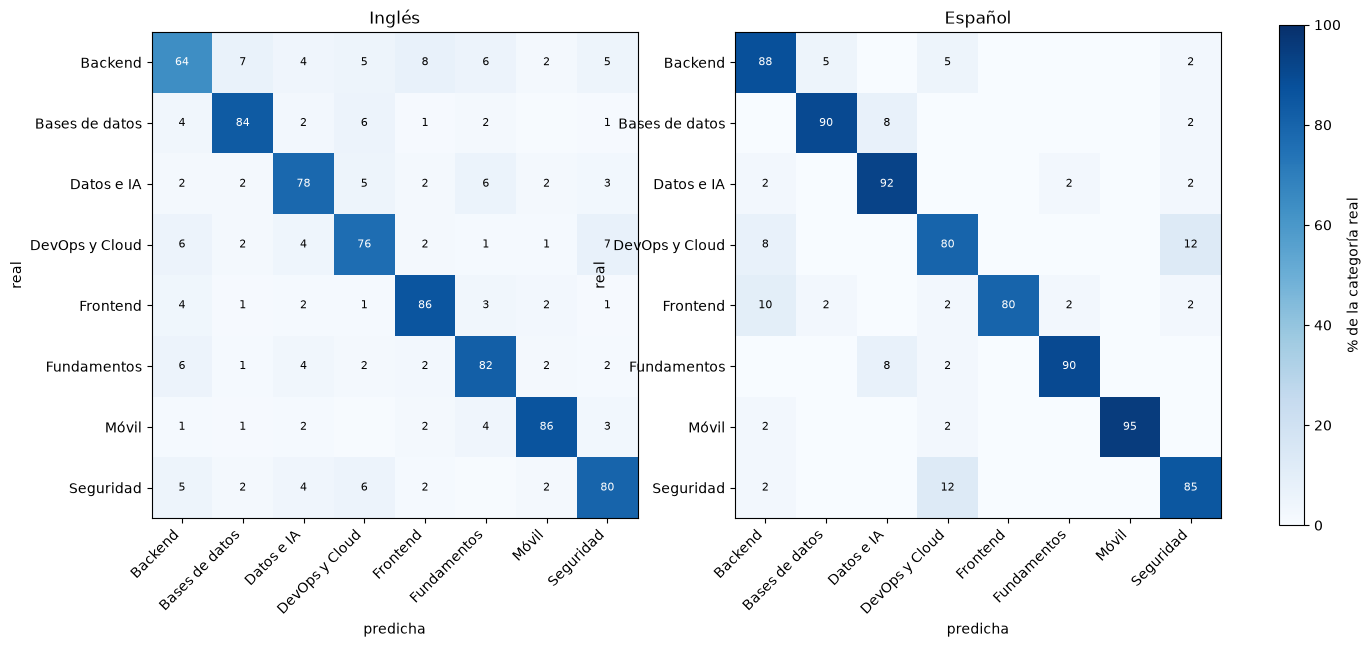

In [11]:
def confusion_heatmap(ax, y_true, y_pred, title: str):
    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CATEGORIES)))
    percentage = matrix / np.clip(matrix.sum(axis=1, keepdims=True), 1, None) * 100
    names = list(label_encoder.classes_)

    im = ax.imshow(percentage, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
    ax.set_xlabel("predicha"); ax.set_ylabel("real"); ax.set_title(title)

    for i in range(len(names)):
        for j in range(len(names)):
            value = percentage[i, j]
            if value >= 1:      # inferior a 1% sólo ensucia el gráfico
                ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=8,
                        color="white" if value > 55 else "black")
    return im

n_panels = 2 if test_en_df is not None else 1
fig, axes = plt.subplots(1, n_panels, figsize=(7.5 * n_panels, 6.5))
axes = np.atleast_1d(axes)
if test_en_df is not None:
    confusion_heatmap(axes[0], y_test_en, classifier.predict(F_test_en), "Inglés")
im = confusion_heatmap(axes[-1], y_test_es, classifier.predict(F_test_es), "Español")
fig.colorbar(im, ax=axes, fraction=0.03, label="% de la categoría real")
plt.show()

### 8b. Diagnóstico: ¿el idioma o el tipo de texto?

El modelo rinde algo menos en español que en inglés. Pero hay **dos diferencias a la
vez** entre ambos conjuntos, y confundirlas lleva a trabajar en lo que no toca:

- El **idioma** cambia, obviamente.
- El **tipo de texto** también: el corpus mezcla preguntas de foro, largas y con
  código, con artículos divulgativos, cortos y redactados.

Para separarlas se compara por partes: entre fuentes distintas **dentro del mismo
idioma**, y entre idiomas **dentro de la misma fuente**. La segunda comparación es la
única honesta para juzgar la transferencia multilingüe.

La celda imprime la conclusión: si pesa más el idioma, la palanca es ampliar el corpus
en español; si pesa más la fuente, es diversificar el tipo de texto.

También se comprueba que cada categoría tenga **muestra suficiente** en el test
español. La macro-F1 promedia sin ponderar por tamaño, así que una categoría con muy
pocos documentos aporta ruido en lugar de información, y conviene saberlo.

In [12]:
def subset_macro_f1(X, y):
    """macro-F1 sobre las categorías presentes en ese subconjunto."""
    present = np.unique(y)
    score = f1_score(y, classifier.predict(X), labels=present,
                     average="macro", zero_division=0)
    return round(float(score), 4), len(present)

print(f"{'subconjunto':<26}{'docs':>7}{'cats':>6}{'macro-F1':>11}")
print("-" * 50)

scores = {}
if test_en_df is not None:
    for name, key in (("StackOverflow (en)", "stackoverflow"), ("Dev.to (en)", "devto")):
        idx = np.where((test_en_df["source"] == key).values)[0]
        if len(idx) < 20:
            print(f"{name:<26}{len(idx):>7}   (muestra insuficiente)")
            continue
        score, n_cats = subset_macro_f1(F_test_en[idx], y_test_en[idx])
        scores[name] = score
        print(f"{name:<26}{len(idx):>7}{n_cats:>6}{score:>11.4f}")

# El test en español lleva los dos registros en el mismo fichero, y se separan por
# 'source'. La comparación por idioma de abajo solo vale contra Dev.to, que es la misma
# fuente que el test inglés; es.stackoverflow comparte fuente con la mayor parte del
# español de ENTRENAMIENTO, así que evalúa dentro de dominio y da un número más alto.
for name, key in (("Dev.to (es)", "devto"), ("es.stackoverflow (es)", "es-stackoverflow")):
    idx = np.where((test_es_df["source"] == key).values)[0]
    if len(idx) < 20:
        print(f"{name:<26}{len(idx):>7}   (muestra insuficiente)")
        continue
    score, n_cats = subset_macro_f1(F_test_es[idx], y_test_es[idx])
    scores[name] = score
    print(f"{name:<26}{len(idx):>7}{n_cats:>6}{score:>11.4f}")

# Diferencia mínima para afirmar que un efecto domina al otro: por debajo de este
# margen, la distancia entre ambos es indistinguible del ruido de muestreo.
MIN_MARGIN = 0.02

if {"StackOverflow (en)", "Dev.to (en)", "Dev.to (es)"} <= scores.keys():
    source_effect = scores["StackOverflow (en)"] - scores["Dev.to (en)"]
    language_effect = scores["Dev.to (en)"] - scores["Dev.to (es)"]
    print(f"\nDiferencia por FUENTE  (StackOverflow -> Dev.to, mismo idioma): {source_effect:+.4f}")
    print(f"Diferencia por IDIOMA  (Dev.to inglés -> español, misma fuente): {language_effect:+.4f}")

    # Repartir la caída entre fuente e idioma solo tiene sentido si hay una caída.
    # Con el español por encima del inglés, comparar las dos magnitudes elegiría un
    # ganador entre dos cosas que no son caídas.
    if language_effect < 0:
        print("\n=> El español rinde POR ENCIMA del inglés, así que no hay caída que")
        print("   repartir entre fuente e idioma.")
        print("   Con conjuntos de tamaño distinto, esta comparación mide sobre todo la")
        print("   dificultad de cada muestra. Contrasta el detalle por categoría de")
        print("   arriba: si una categoría que falla en inglés acierta mucho más en")
        print("   español, es la muestra española la que es más fácil.")
    elif abs(source_effect - language_effect) < MIN_MARGIN:
        print(f"\n=> Los dos efectos pesan IGUAL (difieren en "
              f"{abs(source_effect - language_effect):.4f}). Ninguno explica el hueco por")
        print("   sí solo: conviene atacar los dos. Más contenido tipo artículo en el")
        print("   entrenamiento, y más español.")
    elif source_effect > language_effect:
        print("\n=> Domina el TIPO DE TEXTO: el modelo entrena con preguntas largas y se")
        print("   evalúa con descripciones cortas. La transferencia multilingüe funciona")
        print("   mejor de lo que sugiere comparar inglés y español directamente.")
    else:
        print("\n=> Domina el IDIOMA: la transferencia entre idiomas es el cuello de")
        print("   botella. Ampliar el corpus en español es la palanca más efectiva.")

    share_es = 100 * train_df["language"].eq("es").mean()
    lado = "por debajo" if language_effect > 0 else "por encima"
    print(f"\nEspañol {lado} del inglés, a igualdad de fuente:")
    print(f"   {scores['Dev.to (en)']:.4f} -> {scores['Dev.to (es)']:.4f}"
          f"  ({abs(100 * language_effect / max(scores['Dev.to (en)'], 1e-9)):.1f} % relativo)")
    print(f"   entrenando con un {share_es:.1f} % de español")

# Fiabilidad del conjunto en español
MIN_SUPPORT = 30
support_es = test_es_df["category"].value_counts()

# La cobertura del registro ARTÍCULO se mira aparte: sumada a las preguntas, cada
# categoría pasa el mínimo y eso esconde que la parte que refleja al producto es fina.
articulos_es = test_es_df[test_es_df["source"] == "devto"]["category"].value_counts()
finas = [c for c in label_encoder.classes_ if articulos_es.get(c, 0) < MIN_SUPPORT]
if finas:
    print(f"\nCon menos de {MIN_SUPPORT} documentos de registro ARTÍCULO en español: "
          f"{len(finas)} de {len(label_encoder.classes_)} categorías")
    for c in finas:
        print(f"     {c:<16} {int(articulos_es.get(c, 0)):>4}")
    print("    En esas categorías el número español se sostiene sobre preguntas de foro.")
reliable = [i for i, c in enumerate(label_encoder.classes_)
           if support_es.get(c, 0) >= MIN_SUPPORT]
scarce = [c for c in label_encoder.classes_ if support_es.get(c, 0) < MIN_SUPPORT]

n_reliable = len(reliable)
if scarce and n_reliable >= 2:
    embedding_macro_f1_es_reliable = round(float(f1_score(
        y_test_es, classifier.predict(F_test_es), labels=reliable,
        average="macro", zero_division=0)), 4)
else:
    embedding_macro_f1_es_reliable = embedding_macro_f1_es

print(f"\nmacro-F1 español, las {len(label_encoder.classes_)} categorías: "
      f"{embedding_macro_f1_es:.4f}")
print(f"macro-F1 español, las {n_reliable} categorías con >= {MIN_SUPPORT} documentos: "
      f"{embedding_macro_f1_es_reliable:.4f}")

# El tamaño del test va junto a la métrica: con unas decenas de documentos por
# categoría, un solo fallo mueve la macro-F1 varios puntos.
if test_en_df is not None:
    print(f"\ndocumentos por categoría en el test: "
          f"{len(test_en_df) // len(CATEGORIES)} en inglés, "
          f"{len(test_es_df) // len(CATEGORIES)} en español")

if scarce:
    print(f"\n⚠️  Categorías con menos de {MIN_SUPPORT} documentos en el test español:")
    for c in scarce:
        print(f"     {c:<16} {int(support_es.get(c, 0)):>4}")
    print("    Amplía SPANISH_TAGS en el notebook de EDA/ETL para darles más muestra.")

subconjunto                  docs  cats   macro-F1
--------------------------------------------------
StackOverflow (en)            760     8     0.7714
Dev.to (en)                  1587     8     0.7903
Dev.to (es)                     0   (muestra insuficiente)
es.stackoverflow (es)           0   (muestra insuficiente)

Con menos de 30 documentos de registro ARTÍCULO en español: 8 de 8 categorías
     Backend             0
     Bases de datos      0
     Datos e IA          0
     DevOps y Cloud      0
     Frontend            0
     Fundamentos         0
     Móvil               0
     Seguridad           0
    En esas categorías el número español se sostiene sobre preguntas de foro.

macro-F1 español, las 8 categorías: 0.8766
macro-F1 español, las 8 categorías con >= 30 documentos: 0.8766

documentos por categoría en el test: 400 en inglés, 40 en español


### 9. Agrupamiento temático

Las 8 categorías son una taxonomía **decidida por el equipo**. KMeans hace algo
distinto y complementario: agrupa los documentos por cómo se parecen entre sí, **sin
mirar las etiquetas**.

Sirve para dos cosas. Al comparar los grupos que encuentra con las categorías reales
se ve si la taxonomía coincide con la estructura natural del contenido. Y el grupo
asignado viaja en el contrato como `cluster_id`, de modo que la aplicación puede
ofrecer "contenido de la misma zona temática" sin depender de la etiqueta.

In [13]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10).fit(X_train)
train_df["cluster"] = kmeans.labels_
print("documentos por grupo:", np.bincount(kmeans.labels_))

documentos por grupo: [1878 1154 1211 1719 2223 2293 1537  785]


### 10. Mapa temático en 2D

Los vectores tienen 384 dimensiones y no se pueden dibujar. UMAP los proyecta a **dos**
conservando la vecindad: lo que estaba cerca en el espacio original sigue cerca en el
plano.

Estas coordenadas `x` e `y` son **las que dibuja el dashboard**. Y como el reductor se
guarda entrenado dentro del artefacto, un contenido nuevo recibe su posición en el
mismo mapa en el momento de entrar, sin reprocesar nada.

In [14]:
umap_reducer = umap.UMAP(n_components=2, random_state=SEED)
coords = umap_reducer.fit_transform(X_train)
train_df["x"] = coords[:, 0]
train_df["y"] = coords[:, 1]
print("proyección 2D lista:", coords.shape)

# El corpus completo, en un solo sitio
# El mapa, la búsqueda y el índice que siembra la base trabajan sobre el corpus
# entero, no sobre el split de entrenamiento. Se arma aquí una vez y se reutiliza en las
# secciones 10, 13, 14 y 16.
# Las coordenadas del entrenamiento salen del ajuste de arriba; las de evaluación de
# transform(), que es el mismo camino que recorre un contenido nuevo en producción.
corpus_parts, vectors = [train_df], [X_train]
for frame, embeddings in ([(test_es_df, X_test_es)] +
                          ([(test_en_df, X_test_en)] if test_en_df is not None else [])):
    projected = frame.copy()
    projected["cluster"] = kmeans.predict(embeddings)
    xy = umap_reducer.transform(embeddings)
    projected["x"], projected["y"] = xy[:, 0], xy[:, 1]
    corpus_parts.append(projected)
    vectors.append(embeddings)

corpus_df = pd.concat(corpus_parts, ignore_index=True)
corpus_vectors = np.vstack(vectors)
assert len(corpus_df) == len(corpus_vectors), "metadatos y vectores desalineados"
print(f"corpus completo: {len(corpus_df)} documentos"
      f"  ({len(train_df)} de entrenamiento + {len(corpus_df) - len(train_df)} de evaluación)")

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


proyección 2D lista: (12800, 2)
corpus completo: 16320 documentos  (12800 de entrenamiento + 3520 de evaluación)


Los mismos documentos, coloreados de dos formas: por la **categoría que les asignó el
equipo** y por el **grupo que descubrió KMeans** sin verlas. Que ambas imágenes se
parezcan indica que la taxonomía refleja la estructura real del contenido.

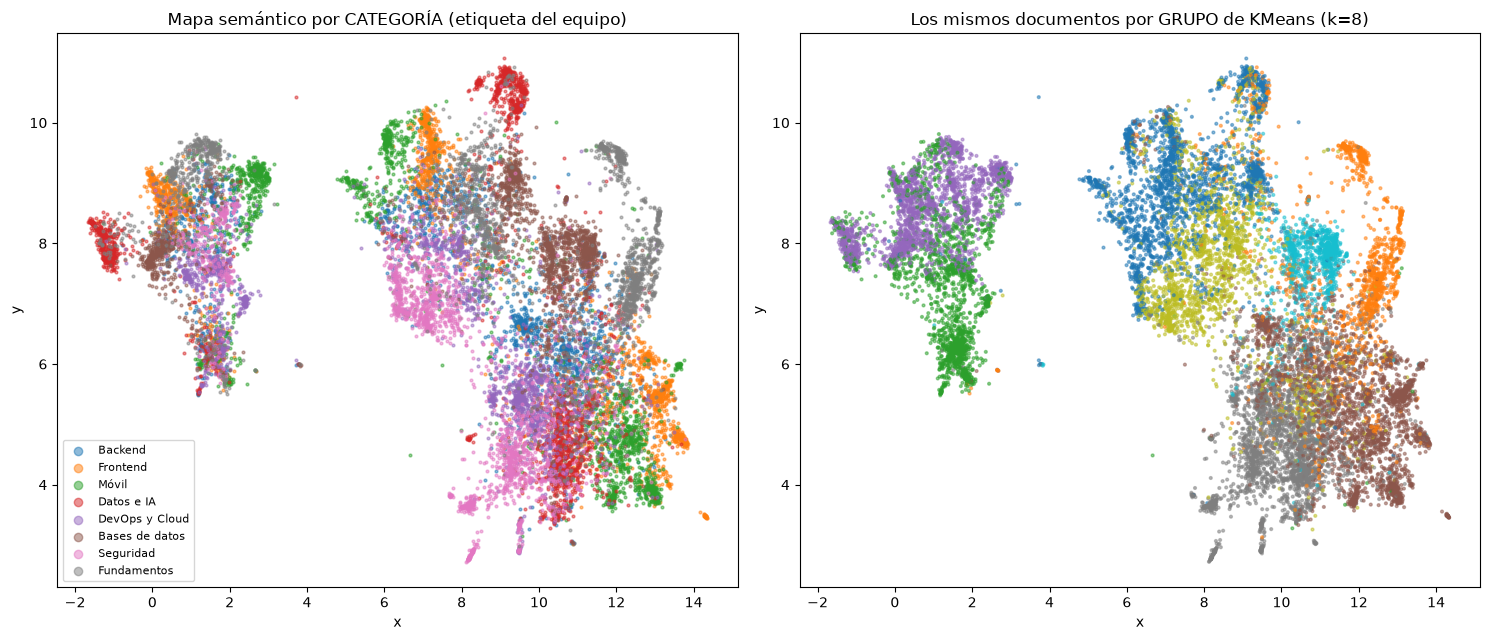

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

for color, category in zip(COLORS, CATEGORIES):
    mask = corpus_df["category"] == category
    ax1.scatter(corpus_df.loc[mask, "x"], corpus_df.loc[mask, "y"],
                s=4, alpha=0.5, color=color, label=category)
ax1.set_title("Mapa semántico por CATEGORÍA (etiqueta del equipo)")
ax1.legend(markerscale=3, fontsize=8, loc="best")

ax2.scatter(corpus_df["x"], corpus_df["y"], s=4, alpha=0.5,
            c=corpus_df["cluster"], cmap="tab10")
ax2.set_title(f"Los mismos documentos por GRUPO de KMeans (k={N_CLUSTERS})")

for ax in (ax1, ax2):
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

### 11. Palabras clave

Para cada contenido se extraen los términos que **mejor lo distinguen del resto del
corpus**. No son las palabras más repetidas —esas serían siempre las mismas— sino las
que aparecen en este texto y son raras en los demás.

El vocabulario se construye con documentos **en los dos idiomas**, de forma que un
texto en español encuentre términos en español con los que emparejar.

In [16]:
keyword_corpus = train_docs + test_es_docs        # inglés + español
keyword_vectorizer = TfidfVectorizer(**TFIDF_PARAMS).fit(keyword_corpus)
_kw_features = np.array(keyword_vectorizer.get_feature_names_out())

def _is_noise(term: str) -> bool:
    """Descarta términos formados solo por conectores ('de la', 'of the')."""
    return all(token in STOPWORDS for token in term.split())

def keywords(text: str, top_n: int = N_KEYWORDS) -> list:
    weights = keyword_vectorizer.transform([text]).toarray()[0]
    ranked = (_kw_features[i] for i in weights.argsort()[::-1] if weights[i] > 0)
    return [term for term in ranked if not _is_noise(term)][:top_n]

print(keywords("Introducción a Spring Boot y creación de APIs REST con Java"))
print(keywords("Indexing strategies to speed up slow PostgreSQL queries"))

['apis rest', 'rest java', 'introduccion', 'creacion', 'apis', 'rest']
['speed up', 'strategies', 'indexing', 'speed', 'slow', 'queries']


## Parte B — Uso

Hasta aquí, el entrenamiento. Lo que sigue muestra **cómo se usa** el modelo: el
contrato que consume la aplicación, la búsqueda semántica y cómo crece la base de
conocimiento.

### 12. El contrato del servicio

Esto es exactamente lo que el servicio de inferencia devuelve por cada contenido, y
sobre lo que construye el backend.

| Campo | Qué es |
|---|---|
| `category` | una de las 8 categorías |
| `probability` | cuánta confianza tiene el modelo en esa categoría |
| `keywords` | términos que definen el contenido |
| `explanation` | términos que justifican **por qué** esa categoría |
| `cluster_id` | grupo temático al que pertenece |
| `x`, `y` | posición en el mapa del dashboard |
| `embedding` | vector de 384 números; es lo que permite encontrar contenido relacionado |

Las claves van en inglés porque forman parte del contrato con el backend; los
**valores** de categoría van en español porque los ve la persona usuaria.

`explanation` sale del modelo explicable: son los términos concretos del texto que
más pesaron hacia la categoría elegida. Es lo que convierte la predicción en algo
auditable en lugar de una caja negra.

In [17]:
def explain(document: str, category: str, top_n: int = N_EXPLANATION) -> list:
    """Términos del documento que más empujaron hacia la categoría predicha."""
    vector = baseline_vectorizer.transform([document])
    index = int(label_encoder.transform([category])[0])
    coef = baseline_classifier.coef_[index] if baseline_classifier.coef_.shape[0] > 1 else baseline_classifier.coef_[0]
    contribution = vector.multiply(coef).toarray()[0]
    ranked = (baseline_feature_names[i] for i in contribution.argsort()[::-1] if contribution[i] > 0)
    return [term for term in ranked if not _is_noise(term)][:top_n]

def predict(title: str, body: str) -> dict:
    """Todo lo que el servicio de inferencia devuelve por un contenido."""
    document = f"{title}. {body}"
    vector = embed_documents([document])            # embedding: va a la base de datos
    features = build_features(vector, [document])   # embedding + vocabulario: lo clasifica
    probabilities = classifier.predict_proba(features)[0]
    best = int(np.argmax(probabilities))
    category = label_encoder.classes_[best]
    # El grupo y las coordenadas se calculan sobre el embedding, no sobre las
    # características de clasificación, para que vivan en el mismo espacio que la
    # base de datos usa para buscar.
    x, y = umap_reducer.transform(vector)[0]
    return {
        "category":    category,
        "probability": round(float(probabilities[best]), 4),
        "keywords":    keywords(document),
        "explanation": explain(document, category),
        "cluster_id":  int(kmeans.predict(vector)[0]),
        "x":           round(float(x), 4),
        "y":           round(float(y), 4),
        "embedding":   [round(float(v), 6) for v in vector[0]],
    }

demo = predict("Introducción a Spring Boot",
               "Creación de APIs REST con Java y Spring Boot: controladores, inyección de dependencias y manejo de excepciones.")
print(json.dumps({k: (v if k != "embedding" else f"[{len(v)} floats]") for k, v in demo.items()},
                 indent=2, ensure_ascii=False))

{
  "category": "Backend",
  "probability": 0.9947,
  "keywords": [
    "rest java",
    "apis rest",
    "spring boot",
    "boot",
    "inyeccion dependencias",
    "excepciones"
  ],
  "explanation": [
    "spring",
    "spring boot",
    "boot",
    "rest",
    "java"
  ],
  "cluster_id": 2,
  "x": 2.1937,
  "y": 6.067,
  "embedding": "[384 floats]"
}


### 13. Búsqueda semántica

Buscar por **significado**, no por coincidencia de palabras. Una consulta y un
documento pueden no compartir ni un término y aun así ser lo mismo — incluso estando
en idiomas distintos.

Aquí se demuestra en memoria. **En producción esta búsqueda corre dentro de la
Autonomous Database** con `VECTOR_DISTANCE`: la aplicación pide el vector de la
consulta y la base resuelve el ranking, sin traer los documentos a la aplicación.

In [18]:
def search(query: str, top_n: int = 5) -> list:
    q = embed_queries([query])[0]
    scores = corpus_vectors @ q
    order = scores.argsort()[::-1][:top_n]
    return [{"id": corpus_df.iloc[i]["id"],
             "title": corpus_df.iloc[i]["title"],
             "category": corpus_df.iloc[i]["category"],
             "similarity": round(float(scores[i]), 4)} for i in order]

print(f"Buscando sobre {len(corpus_df)} documentos")
print("Consulta: 'cómo proteger una API con tokens'")
for hit in search("cómo proteger una API con tokens"):
    print(f"  {hit['similarity']:.3f}  [{hit['category']}]  {hit['title']}")

Buscando sobre 16320 documentos
Consulta: 'cómo proteger una API con tokens'
  0.894  [Seguridad]  Dudas sobre la autenticación por token JWT
  0.886  [DevOps y Cloud]  Protección de vídeos con Azure Media Services
  0.880  [Seguridad]  ¿Como obtener el usuario logueado desde una API en laravel?
  0.879  [Móvil]  Almacenamiento clave-valor seguro con EncryptedSharedPreferences y Keychain
  0.876  [Frontend]  Como pasar correctamente un token baerer entre Angular y PHP?


### 14. La base de conocimiento crece

TechMind no es un clasificador: es una base de conocimiento que **se enriquece con cada
contenido que entra**.

Un contenido nuevo pasa por `predict()`, sale con su categoría, su vector, su grupo y
sus coordenadas, la aplicación lo persiste, y **desde ese momento aparece en búsquedas,
en recomendaciones y en el mapa**. Sin reentrenar y sin volver a desplegar.

Esta celda lo demuestra sobre el índice en memoria; en producción ese papel lo cumple
la tabla `contents` de la Autonomous Database.

In [19]:
new_title = "Jetpack Compose en Android"
new_text  = ("Jetpack Compose permite construir interfaces declarativas nativas "
             "en Android con Kotlin, sin ficheros XML de layout.")
QUERY = "interfaces declarativas en Android"

result = predict(new_title, new_text)
print(f"Contenido nuevo -> {result['category']} (confianza {result['probability']:.3f}), "
      f"grupo {result['cluster_id']}, mapa ({result['x']}, {result['y']})\n")

# El índice ampliado es local a esta celda: corpus_df y corpus_vectors no se modifican,
# porque la Parte C los serializa y cualquier cambio aquí acabaría en el artefacto.
index_titles = list(corpus_df["title"]) + [new_title]
index_cats   = list(corpus_df["category"]) + [result["category"]]
index_vectors = np.vstack([corpus_vectors, np.array(result["embedding"], dtype="float32")])
print(f"índice: {len(corpus_vectors)} -> {len(index_vectors)} documentos\n")

q = embed_queries([QUERY])[0]
scores = index_vectors @ q
print(f"Consulta: '{QUERY}'")
for i in scores.argsort()[::-1][:5]:
    marker = "   <-- recién indexado" if i == len(index_vectors) - 1 else ""
    print(f"  {scores[i]:.3f}  [{index_cats[i]}]  {index_titles[i][:55]}{marker}")

position = int((scores.argsort()[::-1] == len(index_vectors) - 1).argmax()) + 1
print(f"\nEl contenido nuevo es recuperable de inmediato (puesto {position}).")

Contenido nuevo -> Móvil (confianza 0.999), grupo 2, mapa (2.7431, 8.1739)

índice: 16320 -> 16321 documentos

Consulta: 'interfaces declarativas en Android'
  0.897  [Móvil]  Jetpack Compose en Android   <-- recién indexado
  0.873  [Móvil]  ¿Como tener acceso a un método declarado en una clase d
  0.870  [Móvil]  Declaración de interfaces reactivas con SwiftUI en iOS
  0.868  [Móvil]  Optimización de layouts móviles con Jetpack Compose
  0.867  [Fundamentos]  Problema con clase abstracta e interfaces

El contenido nuevo es recuperable de inmediato (puesto 1).


### 15. Verificación del contrato

Antes de empaquetar se comprueba que la salida cumple lo acordado con el backend. Si
alguna comprobación falla, **el artefacto no debe subirse**: un modelo que incumple el
contrato rompe la aplicación en producción, no aquí.

In [20]:
output = predict("Diseño de índices en bases de datos",
                 "Un índice acelera las lecturas de una tabla a costa de escrituras más lentas y espacio en disco.")

assert set(output) >= {"category", "probability", "keywords", "explanation",
                       "cluster_id", "x", "y", "embedding"}, "faltan claves del contrato"
assert output["category"] in CATEGORIES, "categoría fuera de las 8 oficiales"
assert 0.0 <= output["probability"] <= 1.0
assert isinstance(output["keywords"], list) and isinstance(output["explanation"], list)

# El 'embedding' del contrato son las 384 dimensiones del embedding, no las
# características de clasificación: es lo que se guarda en contents.embedding
# VECTOR(384) y sobre lo que la base hace la búsqueda por similitud.
assert len(output["embedding"]) == EMBEDDING_DIM, (
    f"el contrato debe exponer {EMBEDDING_DIM} floats, no {len(output['embedding'])}")

# El clasificador, en cambio, espera la dimensión combinada. Son dos números
# distintos, al confundirlos el error no es visible, por eso se comprueban por separado.
assert classifier.n_features_in_ == EMBEDDING_DIM + (SVD_COMPONENTS or 0), (
    f"el clasificador espera {classifier.n_features_in_} características")
if svd is not None:
    assert svd.n_components == SVD_COMPONENTS
    assert build_features(np.zeros((1, EMBEDDING_DIM), dtype="float32"),
                          ["texto de prueba"]).shape[1] == classifier.n_features_in_

print(f"✅ contrato verificado — {EMBEDDING_DIM} dimensiones a la base de datos, "
      f"{classifier.n_features_in_} al clasificador")

✅ contrato verificado — 384 dimensiones a la base de datos, 884 al clasificador


## Parte C — Empaquetado

### 16. Serialización

Se generan **dos artefactos** con destinos distintos:

| Artefacto | Contiene | Quién lo usa |
|---|---|---|
| `model/model.joblib` | los modelos entrenados | el servicio de inferencia, al arrancar |
| `model/corpus_index.npz` | los vectores del corpus y sus metadatos | la carga inicial de la base de datos |

Los metadatos del índice traen **una fila por columna de la tabla `contents`**:
`id`, `title`, `body`, `category`, `source`, `url`, `language`, `keywords`,
`cluster`, `x`, `y`. El `body` es obligatorio en la tabla, así que viaja aquí; y
`cluster` se llama `cluster_id` en la base, porque `CLUSTER` es palabra reservada
en Oracle.

**El índice lleva el corpus completo: entrenamiento y evaluación.** La división
train/test sirve para medir el modelo con honestidad, y esa es toda su función. Para
la biblioteca de contenidos no significa nada: quien busca *"cómo proteger una API"*
merece encontrar el documento tanto si cayó en el conjunto de entrenamiento como en
el de evaluación. Indexar solo el entrenamiento escondería uno de cada cinco
documentos de las búsquedas, las recomendaciones y el mapa.

Las métricas se calcularon antes, con modelos entrenados solo sobre el conjunto de
entrenamiento, y el modelo nunca lee el índice: son dos caminos que no se cruzan.

La separación entre los dos artefactos no es un detalle de implementación. **Los
vectores del corpus no van en el joblib**: el joblib se regenera solo al reentrenar,
mientras que los contenidos crecen constantemente. Manteniéndolos en la base de datos,
añadir contenido no exige regenerar ni redesplegar nada.

Por la misma lógica, **el modelo de embeddings tampoco viaja en el artefacto**: son
unos 470 MB que se incluyen en la imagen del servicio. En el joblib solo va su nombre.
Así el archivo pesa kilobytes en lugar de cientos de megas.

In [21]:
# El índice cubre el corpus completo: entrenamiento y evaluación
# La división train/test mide el modelo sin hacer trampa. Para la base de conocimiento
# no significa nada: los tres conjuntos son contenido publicable y los tres se indexan.
# Las métricas ya están calculadas arriba con modelos entrenados solo sobre train, y el
# modelo nunca lee el índice, así que indexarlo entero no toca ninguna evaluación.
#
# corpus_df y corpus_vectors se armaron en la sección 10, y son los mismos que usan el
# mapa y la búsqueda. Aquí solo falta añadir las palabras clave.
corpus_df["keywords"] = [keywords(f"{row.title}. {row.body}")
                         for row in corpus_df.itertuples()]

# Se comprueba antes de escribir: cubre el corpus entero, los metadatos van alineados
# con los vectores y no hay id repetidos. Si alguien serializa un
# subconjunto, la celda falla aquí en lugar de publicar un índice corto en silencio.
expected = len(train_df) + len(test_es_df) + (len(test_en_df) if test_en_df is not None else 0)
assert len(corpus_df) == expected, f"el índice cubre {len(corpus_df)} de {expected} documentos"
assert len(corpus_df) == len(corpus_vectors), "metadatos y vectores desalineados"
assert corpus_df["id"].is_unique, "hay identificadores repetidos en el índice"

# Términos más definitorios de cada categoría, según el modelo explicable. Viajan en
# los metadatos para que la aplicación pueda mostrar de qué trata cada categoría.
terms_by_category = {
    category: baseline_feature_names[baseline_classifier.coef_[i].argsort()[::-1][:10]].tolist()
    for i, category in enumerate(label_encoder.classes_)
}

# model.joblib: solo los modelos
artifact = {
    "meta": {
        "version": MODEL_VERSION,
        "embedding_model": EMBEDDING_MODEL,
        "dim": EMBEDDING_DIM,                    # embedding: lo que va a la base de datos
        "feature_dim": int(F_train.shape[1]),    # lo que espera el clasificador
        "svd_components": SVD_COMPONENTS,
        "classifier_c": CLASSIFIER_C,
        "doc_prefix": DOC_PREFIX,
        "query_prefix": QUERY_PREFIX,
        "categories": label_encoder.classes_.tolist(),
        "n_clusters": N_CLUSTERS,
        "terms_by_category": terms_by_category,
        # Cuando no hay test_corpus.jsonl las métricas en inglés tomarán el valor None : el
        # conjunto es opcional (sección 4) y su ausencia no afecta el artefacto.
        "metrics": {
            "embedding_macro_f1_en": embedding_macro_f1_en,
            "embedding_macro_f1_es": embedding_macro_f1_es,
            "tfidf_macro_f1_en": tfidf_macro_f1_en,
            "tfidf_macro_f1_es": tfidf_macro_f1_es,
            "embedding_macro_f1_es_reliable": embedding_macro_f1_es_reliable,
            "es_reliable_categories": n_reliable,
            "es_min_support": MIN_SUPPORT,
        },
        "train_size": len(train_df),    # documentos con los que aprendió el modelo
        "index_size": len(corpus_df),    # documentos que van a la base de datos
    },
    "classifier": classifier,               # espera 'feature_dim' características
    "svd": svd,                             # comprime el vocabulario; None si está desactivado
    "label_encoder": label_encoder,
    "keyword_vectorizer": keyword_vectorizer,
    "baseline_vectorizer": baseline_vectorizer,
    "baseline_classifier": baseline_classifier,
    "kmeans": kmeans,                       # grupo de un contenido nuevo
    "umap_reducer": umap_reducer,           # coordenadas de un contenido nuevo
}
joblib.dump(artifact, MODEL_PATH, compress=3)

# --- corpus_index.npz: vectores y metadatos para poblar la base de datos ---
# 'body' viaja en el índice porque contents.body es NOT NULL: sin él, el sembrado de
# la tabla falla en la primera fila. 'keywords' se calcula con la misma función que
# usa POST /predict, para que los documentos del corpus y los que entran por la
# aplicación traigan palabras clave comparables (una transformación por documento).
INDEX_FIELDS = ["id", "title", "body", "category", "source", "url", "language",
                "keywords", "cluster", "x", "y"]
corpus_metadata = corpus_df[INDEX_FIELDS].to_dict("records")
np.savez_compressed(INDEX_PATH,
                    embeddings=corpus_vectors.astype("float32"),
                    metadata=np.array(corpus_metadata, dtype=object))

print(f"{str(MODEL_PATH):<26} {MODEL_PATH.stat().st_size / 1e6:>7.2f} MB")
print(f"{str(INDEX_PATH):<26} {INDEX_PATH.stat().st_size / 1e6:>7.2f} MB "
      f"({len(corpus_metadata)} documentos)")
print(f"\níndice = entrenamiento {len(train_df)}"
      f" + test español {len(test_es_df)}"
      f" + test inglés {len(test_en_df) if test_en_df is not None else 0}"
      f" = {len(corpus_df)}")

model/model.joblib          156.73 MB
model/corpus_index.npz       29.10 MB (16320 documentos)

índice = entrenamiento 12800 + test español 320 + test inglés 3200 = 16320


### 17. Publicación en OCI Object Storage

Los artefactos se suben a un bucket, desde donde el servicio de inferencia los
descarga al arrancar. Un archivo `latest.txt` indica qué versión está activa, lo que
permite publicar una versión nueva y volver atrás cambiando una sola línea.

> **El puntero se sube siempre el último.** Si `latest.txt` apuntara a una versión
> cuyos archivos aún se están subiendo, cualquier servicio que arranque en ese
> intervalo intentaría cargar algo que todavía no existe.

In [22]:
BUCKET = "techmind-data"
PREFIX = f"models/{MODEL_VERSION}/"

LATEST_PATH.write_text(PREFIX)

commands = [
    f"oci os object put --bucket-name {BUCKET} --file {MODEL_PATH}  --name {PREFIX}model.joblib --force",
    f"oci os object put --bucket-name {BUCKET} --file {INDEX_PATH}  --name {PREFIX}corpus_index.npz --force",
    f"oci os object put --bucket-name {BUCKET} --file {LATEST_PATH} --name models/latest.txt --force",
]

print("Ejecuta estos comandos con el OCI CLI configurado:\n")
for command in commands:
    print(" ", command)

Ejecuta estos comandos con el OCI CLI configurado:

  oci os object put --bucket-name techmind-data --file model/model.joblib  --name models/v1/model.joblib --force
  oci os object put --bucket-name techmind-data --file model/corpus_index.npz  --name models/v1/corpus_index.npz --force
  oci os object put --bucket-name techmind-data --file model/latest.txt --name models/latest.txt --force
